# Notebook to read PEATMAP data and rasterize it 


Table of content of the notebook
* [Classical import](#import)
* [Path to the different folders and files used across the notebook](#allpaths)
* [Unzip PEATMAP files](#filemanip)
* [Shape file to dataframe](#shp2df) 
* [Authentification GEE](#gee_auth)
    * [Select the shapefile from an given AOI](#select_shp)
    * [Function to plot all the shapefile on a google map](#plotallshp")
    * [Function to check the coverage of the shape files](#chkcoverage)
    * [Function to crop the shape file to the AOI](#cropshp)
* [Rasterisation of the shapefiles](#rastershp)

<a class="anchor" id="select_shp"></a>


**DATA**

Source of the peatmap data : https://archive.researchdata.leeds.ac.uk/251/

Related to the article: 

Xu, J., Morris, P. J., Liu, J., & Holden, J. (2018). PEATMAP: Refining estimates of global peatland distribution based on a meta-analysis. Catena, 160, 134-140. https://doi.org/10.1016/j.catena.2017.09.010




## Classical imports <a class="anchor" id="import"></a>

In [1]:
import sys, os

from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import geopandas as gpd

# allow images to display in the notebook
from IPython.display import Image

# remove warnings
import warnings
warnings.filterwarnings('ignore')

# import libraries
import json
from libPeatland import *
from libLandsat8 import *

## User parameters

In [3]:
# Region of interest
AOI = {"xmin": -103.1, "ymin": 47.9, "xmax": -79.2, "ymax": 60.5} # Hudson Bay
#AOI ={"xmin": 58.5, "ymin": 54.8, "xmax": 90.1, "ymax": 70.7} # Russia
#AOI = {"xmin": 24, "ymin": 62.9, "xmax": 29.06, "ymax": 68.1} # Finland

# Parameters
plot_maps = True
verbose = False

# -.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
# Peatland parameters
# -.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
update_shape_df = False
peatland_param_file = "peatland_params.json"

# -.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
# Landsat 8 parameters
# -.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
# Prepare LANDSAT data ? 
prepare_landsat_data = False

# Define the dates range
ls8_start_date = '2013-01-01'    
ls8_end_date = '2023-11-30' 

# Define the months range
ls8_start_month = 5
ls8_end_month   = 9  # before the snow  



In [4]:
# Plot the AOI on a map
if plot_maps:
    import folium # the folium library
    world_map = folium.Map(zoom_start=2)

    # add a rectangle to the map
    folium.Rectangle(
        bounds=[(AOI["ymin"], AOI["xmin"]), (AOI["ymax"], AOI["xmax"])],
        fill=True,
        fill_color="red",
        fill_opacity=0.2,
        popup="Area of interest",
    ).add_to(world_map)

    # add the AOI to the map
    folium.Marker(
        location=[(AOI["ymin"]+AOI["ymax"])/2, (AOI["xmin"]+AOI["xmax"])/2],
        tooltip="Click me!",
        popup="Center of you AOI",
        icon=folium.Icon(icon="cloud"),
    ).add_to(world_map)

    world_map.fit_bounds(world_map.get_bounds())
    display(world_map)

## Load the LANDSAT data

If requested, the LANDSAT data are downloaded and prepared for the analysis. 
The data are downloaded from Google Earth Engine and first stored in your Google Drive.
You need to have a Google account and to have access to Google Earth Engine.

Then, after preparing the data, you need to retrieve them from your Google Drive and to store them in the data folder.

In [5]:
if prepare_landsat_data:
# Define the Earth Engine object, using the authentication credentials.
    # It will ask you to authenticate using your google account.
    # You will need to copy and paste a code in the terminal
    ee.Authenticate()

    # Initialize the Earth Engine object, using the authentication credentials.
    ee.Initialize()

    AOI_coord = [AOI["xmin"], AOI["ymin"], AOI["xmax"], AOI["ymax"]]
    AOI = ee.Geometry.Rectangle(AOI_coord, 'EPSG:4326', False)
 
    print("Start date: ", ls8_start_date)
    print("End date: ", ls8_end_date)

    print("Start month: ", ls8_start_month)
    print("End month: ", ls8_end_month)
    
    # Extract the data from the LANDSAT8 images from Google Earth Engine
    extract_ls8_data(AOI, ls8_start_date, ls8_end_date,
                        ls8_start_month, ls8_end_month)
    
else:
    print("LANDSAT8 data already extracted")
    print("Don't forget to retrieve the data from Google Earth Engine")
    

LANDSAT8 data already extracted
Don't forget to retrieve the data from Google Earth Engine


## Path to the different folders and files used across the notebook <a class="anchor" id="allpaths"></a>

In [7]:
# All the paths are stored in a JSON file named peatland_params.json
# This file is stored in the same directory as the notebook
# The JSON file is loaded and the paths are stored in variables

# Beware that there is no param file in the repo.

# The JSON file is structured as follows:
# {
#     "PEATMAP": "path/to/PEATMAP",
#     "LS8": "path/to/LS8",
#     "MERIT": "path/to/MERIT",
#     "WTD": "path/to/WTD"
# }

# Load the JSON file
with open(peatland_param_file) as json_file:
    datadir = json.load(json_file)

PEATMAP_DATA_DIR = datadir["PEATMAP"]
PEATMAP_DATA_DIR_WD = datadir["PEATMAP_WD"]
LS8_DATA_DIR = datadir["LS8"]
LS8_DATA_DIR_WD = datadir["LS8_WD"]
MERIT_DATA_DIR = datadir["MERIT"]
MERIT_DATA_DIR_WD = datadir["MERIT_WD"]
WTD_DATA_DIR = datadir["WTD"]
WTD_DATA_DIR_WD = datadir["WTD_WD"]

print("PEATMAP data directory: ", PEATMAP_DATA_DIR)
print("PEATMAP data directory (output directory): ", PEATMAP_DATA_DIR_WD)
print("LANDSAT8 data directory: ", LS8_DATA_DIR)
print("LANDSAT8 data directory (output directory): ", LS8_DATA_DIR_WD)
print("MERIT data directory: ", MERIT_DATA_DIR)
print("MERIT data directory (output directory): ", MERIT_DATA_DIR_WD)
print("WTD data directory: ", WTD_DATA_DIR)
print("WTD data directory (output directory): ", WTD_DATA_DIR_WD)


PEATMAP data directory:  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/2_PEATMAP_DP/PEATMAP_raw
PEATMAP data directory (output directory):  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/2_PEATMAP_DP/PEATMAP_welldone
LANDSAT8 data directory:  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/1_GEE_DP/LS8_raw
LANDSAT8 data directory (output directory):  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/1_GEE_DP/LS8_welldone
MERIT data directory:  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/3_MERIT_DP/
MERIT data directory (output directory):  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/3_MERIT_DP/MERIT_welldone
WTD data directory:  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/4_WTD_DP
WTD data directory (output directory):  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/4_WTD_DP/WTD_welldone


## Unzip PEATMAP files <a class="anchor" id="filemanip"></a>

In the next cell, we just unzip all the files .zip, to access the shape files.
Data from the PEATMAP article come from : https://archive.researchdata.leeds.ac.uk/251/

- All the zip files can be loaded into your `PEATMAP_DATA_DIR` 
- `unzip_files` function as its name says, unzip all the file in directories according to the location.
- Zipped files are moved into a directory `zip_files`. 

In [8]:
# Unzip the files in the directory
list_zip_files = unzip_files(PEATMAP_DATA_DIR)

No zip files to unzip


## Shape files to  Dataframe <a class="anchor" id="shp2df"></a>

Fonction to read all the shapefile and create a dataframe and a XML file to save all the information 

In [9]:
# check if shapefiles_bounding_box.xml exists
if os.path.exists(os.path.join(PEATMAP_DATA_DIR, "shapefiles_bounding_box.xml")):
    print("shapefiles_bounding_box.xml already exists")
    if update_shape_df:
        print("Update the file requested")
        df_shapefiles = shapesfile2df(PEATMAP_DATA_DIR, verbose=verbose, export=True,
                              export_path=PEATMAP_DATA_DIR, export_name="shapefiles_bounding_box.xml")
        print(df_shapefiles)
else:

    df_shapefiles = shapesfile2df(PEATMAP_DATA_DIR, verbose=verbose, export=True,
                              export_path=PEATMAP_DATA_DIR, export_name="shapefiles_bounding_box.xml")
    display(df_shapefiles)

shapefiles_bounding_box.xml already exists


## Authentication to Google Earth Engine <a class="anchor" id="gee_auth"></a>

In [10]:
import ee

ee.Authenticate()

# Initialize the Earth Engine object, using the authentication credentials.
ee.Initialize()

## Select the shapefile from an given AOI <a class="anchor" id="select_shp"></a>

In [11]:
# Check if the shapefiles_bounding_box.xml exists
if os.path.exists(os.path.join(PEATMAP_DATA_DIR, "shapefiles_bounding_box.xml")):
    df_shapefiles = pd.read_xml(os.path.join(PEATMAP_DATA_DIR, "shapefiles_bounding_box.xml"))
    display(df_shapefiles)
else:
    print("shapefiles_bounding_box.xml does not exist")

,xmin,ymin,xmax,ymax,zone_name,country_name,file_name,path
0,-16.330076,-34.017252,50.477910,36.913021,Africa,AF,AF_Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
1,74.203657,18.339348,140.540375,55.909992,Asia,EA,EA_Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
2,96.919706,40.295416,144.556779,51.641090,Asia,Histosols_Hokkaido_Mongolia_North Korea,Histosols_Hokkaido_Mongolia_North Korea.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
3,26.767321,5.940900,86.644495,39.950910,Asia,NEA,NEA_Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
4,77.261010,-9.385781,143.643095,33.799779,Asia,SEA,SEA_Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
5,-179.999989,46.312551,179.999989,73.950526,Asia,SIB,SIB_Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
6,-10.453172,50.057605,1.718516,60.847681,Europe,British Isles Peatland,British Isles Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
7,19.525267,59.826673,31.584391,70.058332,Europe,Finland,Finland_Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
8,4.893026,58.055995,30.907914,70.654473,Europe,Norway,Norway_Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...
9,-22.447181,35.919434,59.081063,69.949844,Europe,Other_European,Other_European_Peatland.shp,/home/gsainton/CALER/PEATMAP/0_data_preprocess...


### Plot all the shapefile on a google map <a class="anchor" id="plotallshp"></a>

In [12]:
if plot_maps:
    plot_all_shapefiles(df_shapefiles)


### Function to check the coverage of the shape files <a class="anchor" id="chkcoverage"></a>

Which files covers the best, a given AOI

Zone name:  North_America
Shapefile name:  Canada_Peatland.shp
Shapefile path:  /home/gsainton/CALER/PEATMAP/0_data_preprocessing/2_PEATMAP_DP/PEATMAP_raw/North_America/Canada_Peatland.shp
Surface:  2738.5188572977177


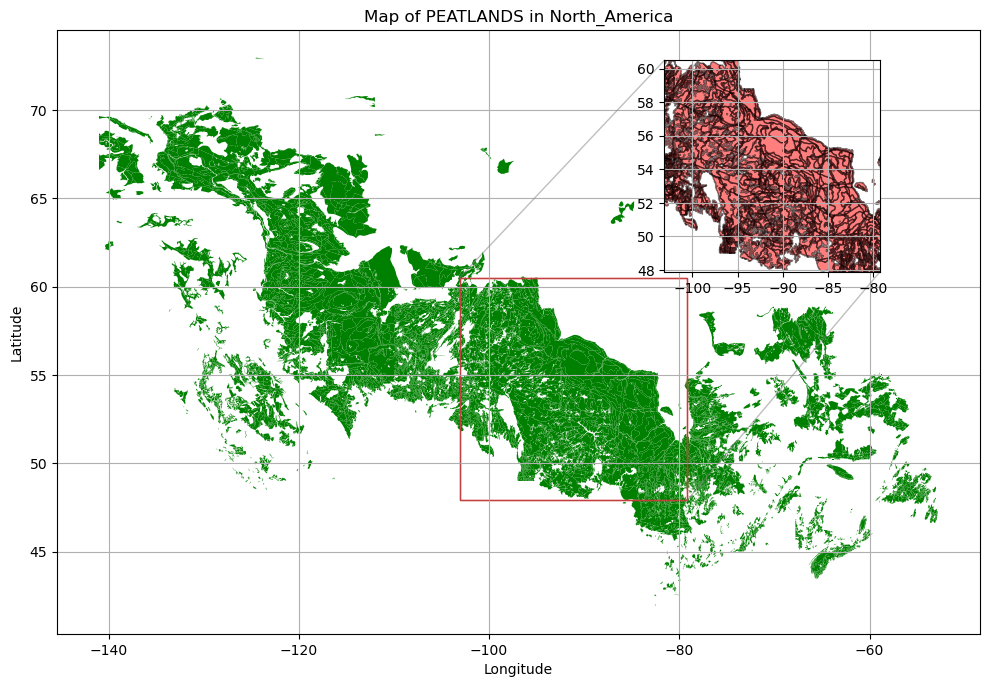

In [13]:
# Check if the zone is covered by one of the shapefiles
covered, dict_zone = check_zone_coverage(AOI, df_shapefiles)

# Plot the zone if covered
if covered and plot_maps:
    print("Zone name: ", dict_zone["zone_name"])
    print("Shapefile name: ", dict_zone["file_name"])
    print("Shapefile path: ", dict_zone["file_path"])
    print("Surface: ", dict_zone["surface"])

    # Open the shapefile and print the content the bounding box
    geozone = gpd.read_file(dict_zone["file_path"])
    geozone = geozone.to_crs("EPSG:4326")

    # Plot the shapefile with projection WGS 84
    fig, ax = plt.subplots(figsize=(10, 10))
    geozone.plot(ax=ax, color='green')
    ax.set_title("Map of PEATLANDS in " + dict_zone["zone_name"])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    #ax.set_xlim(geozone.total_bounds[0], geozone.total_bounds[2])
    #ax.set_ylim(geozone.total_bounds[1], geozone.total_bounds[3])
    # grid
    ax.grid()

    # Add the rectangle patch of the AOI_hudson_bay
    from matplotlib.patches import Rectangle
    rect = Rectangle((AOI["xmin"], AOI["ymin"]),
                    AOI["xmax"] - AOI["xmin"],
                    AOI["ymax"] - AOI["ymin"],
                    linewidth=1, edgecolor='r', 
                    facecolor='none')
    ax.add_patch(rect)

    # Add a subplot with the zoom on the AOI_hudson_bay
    axins = ax.inset_axes([0.6, 0.6, 0.35, 0.35])

    geozone.plot(ax=axins, color='red',
                edgecolor='black', alpha=0.5)
    axins.set_xlim(AOI["xmin"], AOI["xmax"])
    axins.set_ylim(AOI["ymin"], AOI["ymax"])
    #axins.set_xticklabels('')
    #axins.set_yticklabels('')
    axins.grid()
    ax.indicate_inset_zoom(axins)


    plt.tight_layout()
    plt.show()
else:
    print("Zone not covered by the PEATLAND shapefiles")

### Function to crop the shape file to the AOI <a class="anchor" id="cropshp"></a>

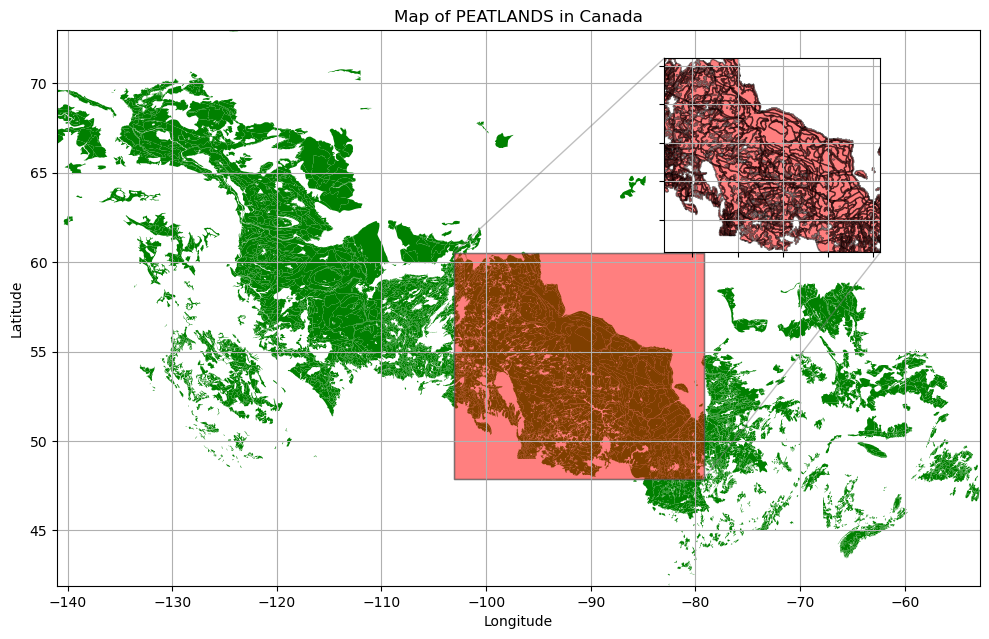

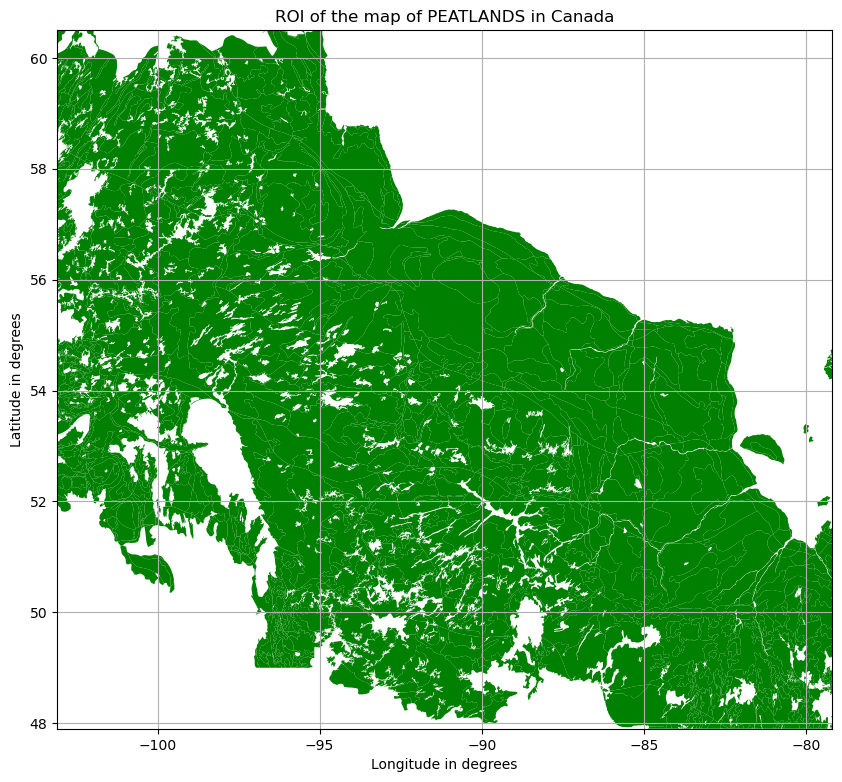

In [15]:
# Crop the shapefile
cropped_shapefile = crop_shapefile(geozone, AOI, plot=plot_maps, export=True, 
                                   export_path=PEATMAP_DATA_DIR_WD, 
                                   export_name=f"cropped_shapefile_{dict_zone['zone_name']}.shp")

# Plot the cropped shapefile
if plot_maps:
    fig, ax = plt.subplots(figsize=(10, 10))
    cropped_shapefile.plot(ax=ax, color='green')
    ax.set_title("ROI of the map of PEATLANDS in Canada")
    ax.set_xlabel("Longitude in degrees")
    ax.set_ylabel("Latitude in degrees")
    ax.set_xlim(cropped_shapefile.total_bounds[0], cropped_shapefile.total_bounds[2])
    ax.set_ylim(cropped_shapefile.total_bounds[1], cropped_shapefile.total_bounds[3])
    ax.grid()
    plt.show()


## Rasterisation shapefile <a class="anchor" id="rastershp"></a>

Rasterisation of the cropped shapefile the same LANDSAT8 resolution

All the LANSAT8 images must be retrieved from your Google Drive manually. 
In the next, we take one of these images as example for its dimension to rasterize the PEATMAP shapefile. 



In [16]:

ls8_file_model = os.path.join(LS8_DATA_DIR, "LS8_B1_5.0.tif")

# Open the LS8 file 
with rasterio.open(ls8_file_model) as src:
    resolution = src.res

pixel_size = resolution[0]

# Rasterize each column of the shapefile into a separate raster file
shp2rasterfile = os.path.join(PEATMAP_DATA_DIR_WD, f"shp2raster_{dict_zone['zone_name']}.tif")
rasterize_shapefile(cropped_shapefile, src, 
                    os.path.join(PEATMAP_DATA_DIR_WD, shp2rasterfile), 
                    pixel_size, attribute="ALL",
                    verbose=verbose, control=True)


Resolution OK
CRS OK
Bounds OK
Shape OK


ERROR 1: PROJ: internal_proj_identify: /home/gsainton/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /home/gsainton/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


Resolution OK
CRS OK
Bounds OK
Shape OK


ERROR 1: PROJ: internal_proj_identify: /home/gsainton/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /home/gsainton/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


Resolution OK
CRS OK
Bounds OK
Shape OK


ERROR 1: PROJ: internal_proj_identify: /home/gsainton/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /home/gsainton/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
